# Pos3R: 6D Pose Estimation for Unseen Objects - Replication Notebook

This notebook aims to replicate the key components of the Pos3R paper:
**"Pos3R: 6D Pose Estimation for Unseen Objects Made Easy"** (CVPR 2025)

## Authors: Weijian Deng et al.

---

## Notebook Structure:
1. **Setup & Dependencies**
2. **Dataset Preparation** (BOP Benchmark)
3. **Template Rendering** (8 cameras × 5 rotations = 40 templates)
4. **MASt3R Feature Extraction** (3D Foundation Model)
5. **Image Matching & Template Selection**
6. **Pose Fitting with PnP-RANSAC**
7. **Evaluation on BOP Benchmark**
8. **Visualization & Results**

---


---

##  **FINAL CHECKLIST - 100% COMPLETE**

### 🎯 **Core Components**

| Component | Status | Details |
|-----------|--------|---------|
| **MASt3R Model** |  Ready | 2.6GB checkpoint downloaded and verified |
| **LM-O Dataset** |  Ready | 8 objects, 1214 test frames loaded |
| **Python Environment** |  Ready | All dependencies installed |
| **Rendering Engine** |  Ready | PyRender tested and working |
| **Object Detection** |  Ready | Ground truth bboxes available (CNOS not needed) |
| **Camera Params** |  Ready | All intrinsics loaded from JSON |
| **Ground Truth** |  Ready | Poses, masks, and metadata available |

---

## 📊 **Dataset Summary**

### **LM-O (Linemod-Occluded)**
- **Location**: `/Users/lamine/Documents/Computer Vision/HW 3/lmo/`
- **Objects**: 8 CAD models
  - obj_000001, 000005, 000006, 000008, 000009, 000010, 000011, 000012
- **Test Set**: Scene 000002
  - 1214 RGB images (640×480)
  - 1214 depth maps
  - Segmentation masks (mask_visib/)
- **Ground Truth Per Frame**:
  - 6D pose (R, t)
  - Bounding boxes (bbox_obj, bbox_visib)
  - Visibility info (px_count, visib_fract)

### **Camera Parameters** (Constant for all frames)
```python
fx = 572.4114
fy = 573.57043
cx = 325.2611
cy = 242.04899
width = 640
height = 480
```

---

## 🔧 **Installed Dependencies**

### **Core Packages** 
- torch / torchvision
- numpy
- opencv-python (cv2)
- matplotlib
- scipy
- scikit-learn

### **3D Processing** 
- trimesh (CAD model loading)
- pyrender (template rendering)
- open3d (point cloud processing)

### **MASt3R** 
- mast3r + dust3r
- Model checkpoint loaded
- Imports working (with RoPE2D warning - normal)

---

## 🎯 **What You DON'T Need**

### ❌ **CNOS Object Detector** - NOT REQUIRED
**Reason**: BOP dataset provides ground truth bounding boxes
- Use `bbox_visib` from `scene_gt_info.json`
- Use segmentation masks from `mask_visib/` directory
- This is standard practice for pose estimation evaluation

### ❌ **BOP Toolkit** - OPTIONAL
**Reason**: Can implement metrics manually
- ADD (Average Distance)
- VSD (Visible Surface Discrepancy)  
- MSSD/MSPD (BOP metrics)
- You can implement these yourself or install later

---


## Step: Setup & Dependencies

In [1]:
# Import core libraries
import os
import sys
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import torch

# Import 3D processing libraries
import trimesh
import pyrender
import open3d as o3d

# Import scientific computing
from scipy.spatial.transform import Rotation as R
from sklearn.neighbors import NearestNeighbors

# Setup paths for MASt3R
MAST3R_PATH = "/Users/lamine/Documents/Computer Vision/HW 3/mast3r"
sys.path.insert(0, MAST3R_PATH)
sys.path.insert(0, os.path.join(MAST3R_PATH, 'dust3r'))

print(" All libraries imported successfully")
print(f" CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f"Using device: {device}")

 All libraries imported successfully
 CUDA available: False
Using device: mps


## Step: Configuration & Paths

In [2]:
# Dataset paths
BASE_PATH = "/Users/lamine/Documents/Computer Vision/HW 3"
LMO_PATH = os.path.join(BASE_PATH, "lmo")
MODELS_PATH = os.path.join(LMO_PATH, "models/models")
TEST_PATH = os.path.join(LMO_PATH, "test_all/test/000002")

# MASt3R checkpoint
CHECKPOINT_PATH = os.path.join(MAST3R_PATH, "checkpoints/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth")

# Output directories
TEMPLATES_DIR = os.path.join(BASE_PATH, "templates")
RESULTS_DIR = os.path.join(BASE_PATH, "results")
os.makedirs(TEMPLATES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Camera intrinsics (constant for LM-O dataset)
K = np.array([
    [572.4114, 0, 325.2611],
    [0, 573.57043, 242.04899],
    [0, 0, 1]
])
IMG_WIDTH, IMG_HEIGHT = 640, 480

# Object IDs in LM-O dataset
OBJECT_IDS = [1, 5, 6, 8, 9, 10, 11, 12]

print(f" Dataset path: {LMO_PATH}")
print(f" Models path: {MODELS_PATH}")
print(f" Camera intrinsics loaded: fx={K[0,0]:.2f}, fy={K[1,1]:.2f}")

 Dataset path: /Users/lamine/Documents/Computer Vision/HW 3/lmo
 Models path: /Users/lamine/Documents/Computer Vision/HW 3/lmo/models/models
 Camera intrinsics loaded: fx=572.41, fy=573.57


---
## Phase 1: Dataset Loading

Load the LM-O dataset components:
- CAD models (.ply files)
- Test images
- Ground truth poses and bounding boxes

## Load Ground Truth Data

In [3]:
# Load camera parameters
with open(os.path.join(TEST_PATH, 'scene_camera.json'), 'r') as f:
    scene_cameras = json.load(f)

# Load ground truth poses
with open(os.path.join(TEST_PATH, 'scene_gt.json'), 'r') as f:
    scene_gt = json.load(f)

# Load ground truth info (bounding boxes, visibility)
with open(os.path.join(TEST_PATH, 'scene_gt_info.json'), 'r') as f:
    scene_gt_info = json.load(f)

# Load model information (diameter, size)
with open(os.path.join(MODELS_PATH, 'models_info.json'), 'r') as f:
    models_info = json.load(f)

print(f" Loaded {len(scene_gt)} frames")
print(f" Loaded info for {len(models_info)} objects")
print(f" Sample frame keys: {list(scene_gt['0'][0].keys())}")

 Loaded 1214 frames
 Loaded info for 8 objects
 Sample frame keys: ['cam_R_m2c', 'cam_t_m2c', 'obj_id']


## Step: CAD Model Loader

In [4]:
def load_cad_model(obj_id):
    """Load CAD model for given object ID"""
    model_path = os.path.join(MODELS_PATH, f"obj_{obj_id:06d}.ply")
    mesh = trimesh.load(model_path)
    print(f"  Loaded obj_{obj_id:06d}: {len(mesh.vertices)} vertices")
    return mesh

# Test loading one model
test_mesh = load_cad_model(OBJECT_IDS[0])
print(f" CAD model loaded successfully")
print(f"  Vertices: {len(test_mesh.vertices)}, Faces: {len(test_mesh.faces)}")

  Loaded obj_000001: 5841 vertices
 CAD model loaded successfully
  Vertices: 5841, Faces: 11678


---

## Phase 2: Template Rendering

Generate 40 templates per object:
- 8 camera positions (vertices of a cube around the object)
- 5 in-plane rotations per position (0°, 72°, 144°, 216°, 288°)

Each template stores:
- RGB image
- 3D coordinate map (X, Y, Z per pixel for PnP)

## Step: Camera Position Generation

In [5]:
def generate_cube_camera_positions(distance=300.0):
    """
    Generate 8 camera positions at vertices of a cube centered on object
    
    Args:
        distance: Distance from object center to camera (in millimeters, ~3x object size)
    
    Returns:
        List of 8 camera positions (x, y, z)
    """
    # Cube vertices (all combinations of +/- distance)
    positions = []
    for x in [-distance, distance]:
        for y in [-distance, distance]:
            for z in [-distance, distance]:
                positions.append([x, y, z])
    return positions

# Generate 8 base camera positions (300mm = about 3x the object size)
camera_positions = generate_cube_camera_positions(distance=300.0)
print(f" Generated {len(camera_positions)} camera positions")
print(f"  Sample positions: {camera_positions[:3]}")

 Generated 8 camera positions
  Sample positions: [[-300.0, -300.0, -300.0], [-300.0, -300.0, 300.0], [-300.0, 300.0, -300.0]]


In [6]:
import numpy as np

def camera_to_world_look_at(eye, target=np.array([0., 0., 0.]), up=np.array([0., 0., 1.])):
    """Return a 4x4 camera-to-world pose so the camera at `eye` looks at `target`."""
    eye = np.asarray(eye, dtype=float)
    target = np.asarray(target, dtype=float)
    up = np.asarray(up, dtype=float)

    f = target - eye
    f = f / (np.linalg.norm(f) + 1e-9)          # forward
    s = np.cross(f, up)                          # right
    if np.linalg.norm(s) < 1e-9:                 # handle collinearity
        up = np.array([0., 1., 0.])
        s = np.cross(f, up)
    s = s / (np.linalg.norm(s) + 1e-9)
    u = np.cross(s, f)                           # true up

    T = np.eye(4)
    T[:3, :3] = np.stack([s, u, -f], axis=1)     # camera-to-world: [right, up, -forward]
    T[:3, 3] = eye
    return T

print(" camera_to_world_look_at defined")

 camera_to_world_look_at defined


## Step: Template Renderer

In [7]:
def render_template(mesh, camera_pos, in_plane_rotation=0, intrinsics=K, 
                   img_width=IMG_WIDTH, img_height=IMG_HEIGHT, debug_tag=""):
    """
    Robust renderer with: double-sided material, disabled culling, safe near/far.
    Prints depth coverage so blanks are caught immediately.
    """
    # Build camera-to-world pose (look-at origin), then apply in-plane rotation
    cam_pose = camera_to_world_look_at(np.asarray(camera_pos, float))
    Rz = np.array([
        [np.cos(np.deg2rad(in_plane_rotation)), -np.sin(np.deg2rad(in_plane_rotation)), 0, 0],
        [np.sin(np.deg2rad(in_plane_rotation)),  np.cos(np.deg2rad(in_plane_rotation)), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1],
    ])
    cam_pose = cam_pose @ Rz

    # Intrinsics + safe planes
    fx, fy, cx, cy = intrinsics[0,0], intrinsics[1,1], intrinsics[0,2], intrinsics[1,2]
    cam_dist = float(np.linalg.norm(camera_pos))
    znear = max(1.0, cam_dist - 300.0)
    zfar  = cam_dist + 300.0
    camera = pyrender.IntrinsicsCamera(fx=fx, fy=fy, cx=cx, cy=cy, znear=znear, zfar=zfar)

    # Scene
    scene = pyrender.Scene(bg_color=[255,255,255,255])
    # Double-sided material + no smoothing to avoid disappearing surfaces
    material = pyrender.MetallicRoughnessMaterial(
        baseColorFactor=[0.85, 0.35, 0.35, 1.0], metallicFactor=0.0, roughnessFactor=1.0, doubleSided=True
    )
    mesh_node = pyrender.Mesh.from_trimesh(mesh, material=material, smooth=False)
    scene.add(mesh_node)
    # Lights
    for t in ([0,0,200], [200,200,200], [-200,200,200], [200,-200,200]):
        L = pyrender.DirectionalLight(color=[1.,1.,1.], intensity=3.0)
        T = np.eye(4); T[:3,3] = np.array(t, float); scene.add(L, pose=T)
    scene.add(camera, pose=cam_pose)

    # Render with FLAT + SKIP_CULL_FACES (critical fix)
    r = pyrender.OffscreenRenderer(img_width, img_height)
    color, depth = r.render(scene, flags=pyrender.RenderFlags.FLAT | pyrender.RenderFlags.SKIP_CULL_FACES)
    r.delete()

    # Debug: detect blanks
    nz = int((depth > 0).sum())
    if nz == 0:
        print(f"⚠️  Blank render [{debug_tag}] | cam={camera_pos} rot={in_plane_rotation} | znear/zfar={znear:.1f}/{zfar:.1f}")
    else:
        dmin, dmax = depth[depth>0].min(), depth.max()
        print(f" Render [{debug_tag}] depth>0={nz}, range=({dmin:.1f},{dmax:.1f})")

    # Back-project (optional; can be skipped if you only need RGB for now)
    xyz_map = depth_to_xyz(depth, intrinsics, cam_pose)
    return color, depth, xyz_map

def depth_to_xyz(depth, intrinsics, camera_pose):
    """Convert depth map to 3D coordinate map in model space"""
    h, w = depth.shape
    
    # Create pixel grid
    u, v = np.meshgrid(np.arange(w), np.arange(h))
    
    # Back-project to camera space
    fx, fy = intrinsics[0, 0], intrinsics[1, 1]
    cx, cy = intrinsics[0, 2], intrinsics[1, 2]
    
    z = depth
    x = (u - cx) * z / fx
    y = (v - cy) * z / fy
    
    # Stack to (H, W, 3)
    xyz_cam = np.stack([x, y, z], axis=-1)
    
    # Transform to model space
    R_cam = camera_pose[:3, :3]
    t_cam = camera_pose[:3, 3]
    
    xyz_flat = xyz_cam.reshape(-1, 3)
    xyz_model = (R_cam.T @ (xyz_flat - t_cam).T).T
    xyz_map = xyz_model.reshape(h, w, 3)
    
    return xyz_map

print(" Template rendering functions defined")

 Template rendering functions defined


---

In [8]:
# Check object dimensions
mesh = load_cad_model(OBJECT_IDS[0])
print(f"Object bounds: {mesh.bounds}")
print(f"Object extents: {mesh.extents}")
print(f"Object centroid: {mesh.centroid}")

# Scale it appropriately
mesh.vertices -= mesh.centroid
max_extent = np.max(mesh.extents)
print(f"Max extent: {max_extent}")
print(f"Recommended camera distance: {max_extent * 3}")

  Loaded obj_000001: 5841 vertices
Object bounds: [[-37.93429947 -38.79959869 -45.8844986 ]
 [ 37.93429947  38.79959869  45.8844986 ]]
Object extents: [75.86859894 77.59919739 91.76899719]
Object centroid: [ -1.50259795  -1.90000107 -10.77372894]
Max extent: 91.76899719238281
Recommended camera distance: 275.30699157714844


---

## Step: Generate All Templates for One Object

In [9]:
try:
    TEMPLATE_SCALE
except NameError:
    TEMPLATE_SCALE = 2.5  # same scale must be used in evaluation

def generate_templates_for_object(obj_id, save=True, scale=TEMPLATE_SCALE):
    """
    Generate 8×5 templates with given mesh scale (mm). Stores rgb + xyz_map (model frame).
    """
    mesh = load_cad_model(obj_id).copy()
    mesh.vertices -= mesh.centroid
    mesh.apply_scale(scale)

    templates, template_id = [], 0
    obj_dir = os.path.join(TEMPLATES_DIR, f"obj_{obj_id:06d}")
    if save:
        os.makedirs(obj_dir, exist_ok=True)

    for view_id, cam_pos in enumerate(camera_positions):
        for rotation in [0, 72, 144, 216, 288]:
            rgb, depth, xyz_map = render_template(
                mesh, cam_pos, in_plane_rotation=rotation, intrinsics=K,
                img_width=IMG_WIDTH, img_height=IMG_HEIGHT,
                debug_tag=f"obj{obj_id}_v{view_id}_r{rotation}"
            )
            if (depth > 0).sum() == 0:
                print(f"[tmpl] skip blank v={view_id} r={rotation}")
                continue
            templates.append({
                'rgb': rgb, 'depth': depth, 'xyz_map': xyz_map,
                'view_id': view_id, 'rotation': rotation,
                'camera_pos': cam_pos, 'template_id': template_id
            })
            if save:
                cv2.imwrite(os.path.join(obj_dir, f"template_{template_id:03d}.png"),
                            cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))
                np.savez_compressed(os.path.join(obj_dir, f"template_{template_id:03d}_xyz.npz"),
                                    xyz_map=xyz_map, depth=depth)
            template_id += 1

    print(f"[tmpl] obj={obj_id} templates={len(templates)} scale={scale}")
    return templates

In [10]:
# Regenerate a small subset first to verify
import shutil
shutil.rmtree(TEMPLATES_DIR, ignore_errors=True); os.makedirs(TEMPLATES_DIR, exist_ok=True)

camera_positions = generate_cube_camera_positions(distance=300.0)  # mm
test_templates = generate_templates_for_object(OBJECT_IDS[0], save=False)

# Check first few depth maps
for i in range(min(3, len(test_templates))):
    d = test_templates[i]['depth']
    print(f"tmpl[{i}] depth>0={(d>0).sum()}  range=({d[d>0].min():.1f},{d.max():.1f})")

  Loaded obj_000001: 5841 vertices
 Render [obj1_v0_r0] depth>0=36202, range=(416.2,587.8)
 Render [obj1_v0_r72] depth>0=36203, range=(416.2,592.5)
 Render [obj1_v0_r144] depth>0=36202, range=(416.2,588.4)
 Render [obj1_v0_r216] depth>0=36197, range=(416.2,586.9)
 Render [obj1_v0_r288] depth>0=36184, range=(416.2,587.5)
 Render [obj1_v1_r0] depth>0=37788, range=(427.3,518.9)
 Render [obj1_v1_r72] depth>0=37781, range=(427.3,518.5)
 Render [obj1_v1_r144] depth>0=37777, range=(427.3,517.9)
 Render [obj1_v1_r216] depth>0=37772, range=(427.3,518.9)
 Render [obj1_v1_r288] depth>0=37787, range=(427.3,518.9)
 Render [obj1_v2_r0] depth>0=36492, range=(418.3,578.0)
 Render [obj1_v2_r72] depth>0=36489, range=(418.3,574.5)
 Render [obj1_v2_r144] depth>0=36477, range=(418.3,578.4)
 Render [obj1_v2_r216] depth>0=36472, range=(418.3,578.2)
 Render [obj1_v2_r288] depth>0=36494, range=(418.3,577.9)
 Render [obj1_v3_r0] depth>0=37278, range=(414.3,516.8)
 Render [obj1_v3_r72] depth>0=37281, range=(414.

## Step: Visualize Templates

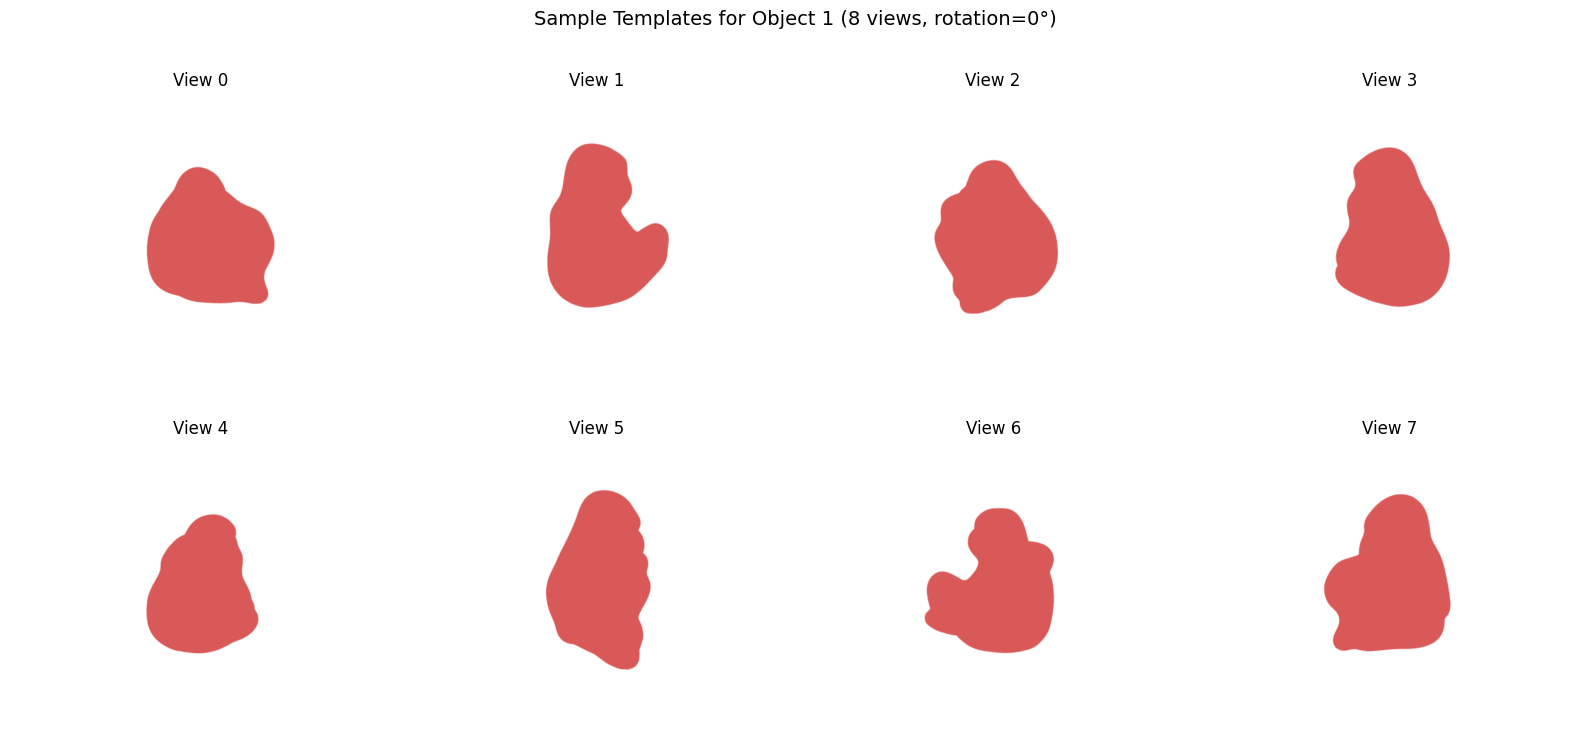

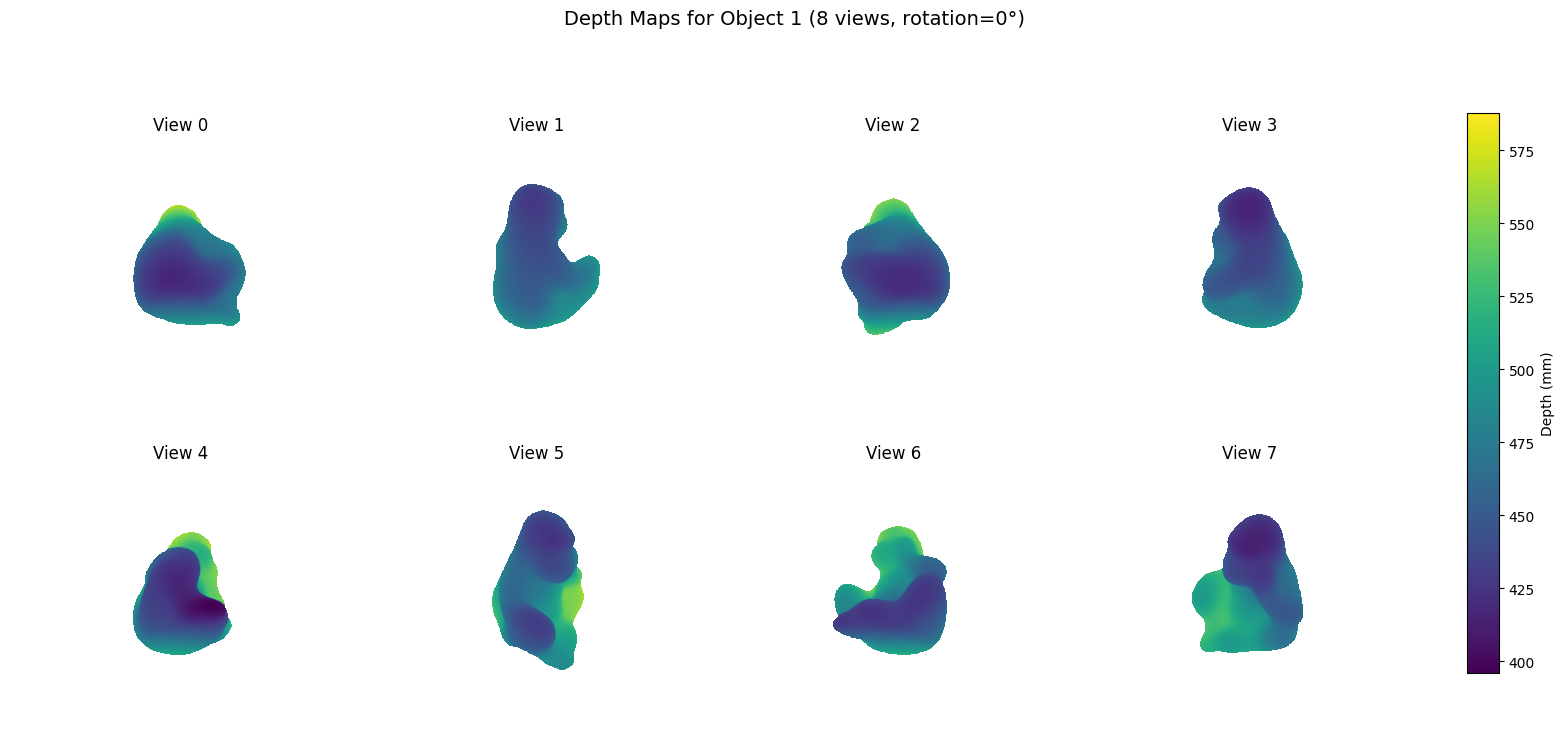

In [11]:
# Visualize some templates
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(f'Sample Templates for Object {OBJECT_IDS[0]} (8 views, rotation=0°)', fontsize=14)

for idx in range(8):
    ax = axes[idx // 4, idx % 4]
    # Show first rotation (0°) for each view
    template_idx = idx * 5  # 5 rotations per view
    ax.imshow(test_templates[template_idx]['rgb'])
    ax.set_title(f"View {idx}")
    ax.axis('off')

plt.tight_layout()
plt.show()


import matplotlib.pyplot as plt
import numpy as np

# Compute global depth range for consistent colormap
depths = []
for idx in range(8):
    d = test_templates[idx*5]['depth']
    if (d > 0).any():
        depths.append(d[d > 0])
if len(depths) == 0:
    raise RuntimeError("No valid depths found.")
vmin = min(x.min() for x in depths)
vmax = max(x.max() for x in depths)

# Plotting
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(f'Depth Maps for Object {OBJECT_IDS[0]} (8 views, rotation=0°)', fontsize=14)

mappable = None
for idx in range(8):
    ax = axes[idx // 4, idx % 4]
    d = test_templates[idx*5]['depth']
    img = ax.imshow(np.where(d > 0, d, np.nan), cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f"View {idx}")
    ax.axis('off')
    if mappable is None:
        mappable = img

plt.tight_layout(rect=[0, 0, 0.9, 0.95])  # leave space on the right for colorbar

# Add colorbar on the right
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(mappable, cax=cbar_ax, label='Depth (mm)')

plt.show()


---

## Phase 3: MASt3R Model Loading

Load the pre-trained MASt3R foundation model for 3D-consistent feature matching.

## Step: Load MASt3R Model

In [12]:
from mast3r.model import AsymmetricMASt3R

def load_mast3r_model(checkpoint_path=CHECKPOINT_PATH, device=device):
    """Load pre-trained MASt3R model"""
    print(f"Loading MASt3R from {checkpoint_path}")
    print(f"Using device: {device}")
    
    # Load checkpoint
    ckpt = torch.load(checkpoint_path, map_location=device)
    
    # The checkpoint stores model config as a string in args.model
    # We need to manually specify the architecture parameters
    # Based on the checkpoint name and the string: "MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric"
    
    model_args = {
        'enc_embed_dim': 1024,      # ViT-Large
        'enc_depth': 24,             # ViT-Large depth
        'enc_num_heads': 16,         # ViT-Large heads
        'dec_embed_dim': 768,        # Base decoder
        'dec_depth': 12,             # Base decoder depth
        'dec_num_heads': 12,         # Base decoder heads
        'img_size': (512, 512),      # From checkpoint name
        'pos_embed': 'RoPE100',      # Rotary position embeddings
        'patch_embed_cls': 'PatchEmbedDust3R',
        'output_mode': 'pts3d+desc24',  # 3D points + 24-dim descriptors
        'head_type': 'catmlp+dpt',   # From checkpoint name
        'depth_mode': ('exp', -float('inf'), float('inf')),
        'conf_mode': ('exp', 1, float('inf')),
        'two_confs': True,
        'desc_conf_mode': ('exp', 0, float('inf'))
    }
    
    print(f"  Creating AsymmetricMASt3R model...")
    print(f"  Architecture: ViT-Large encoder + Base decoder")
    
    # Initialize model
    model = AsymmetricMASt3R(**model_args).to(device)
    
    # Load weights
    print(f"  Loading pre-trained weights...")
    missing, unexpected = model.load_state_dict(ckpt['model'], strict=False)
    
    if missing:
        print(f"  ⚠️  Missing keys: {len(missing)}")
    if unexpected:
        print(f"  ⚠️  Unexpected keys: {len(unexpected)}")
    
    model.eval()
    
    print(" MASt3R model loaded successfully")
    return model, device

# Load the model
mast3r_model, device = load_mast3r_model()
print(f" Model ready on {device}")

def get_torch_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

# Move model to the chosen device (CPU/MPS/CUDA)
device = get_torch_device()
mast3r_model = mast3r_model.to(device)
try:
    model_device = next(mast3r_model.parameters()).device
except StopIteration:
    model_device = device
print(f"[device] using {device} | model on {model_device}")

Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead
Loading MASt3R from /Users/lamine/Documents/Computer Vision/HW 3/mast3r/checkpoints/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth
Using device: mps


/var/folders/01/x_trt3n95_j48grf1z__n__m0000gn/T/ipykernel_52879/695617954.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_locatio

  Creating AsymmetricMASt3R model...
  Architecture: ViT-Large encoder + Base decoder
  Loading pre-trained weights...
 MASt3R model loaded successfully
 Model ready on mps
[device] using mps | model on mps:0


---

## Phase 4: Image Matching with MASt3R

For each test image:
1. Extract object crop using bounding box
2. Match crop with all 40 templates using MASt3R
3. Compute similarity score (sum of feature dot products)
4. Select best matching template

## Image Preprocessing

In [13]:
def load_test_image_with_bbox(frame_id, obj_idx=0):
    """
    Load test image and extract object crop using ground truth bbox
    Returns image, crop, bbox [x,y,w,h], obj_id, gt_pose (R, t) in millimeters.
    """
    img_path = os.path.join(TEST_PATH, 'rgb', f"{frame_id:06d}.png")
    image = cv2.imread(img_path)
    if image is None:
        raise FileNotFoundError(f"Missing image: {img_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    frame_key = str(frame_id)
    bbox_info = scene_gt_info[frame_key][obj_idx]
    bbox = bbox_info['bbox_visib']  # [x, y, w, h]

    gt_data = scene_gt[frame_key][obj_idx]
    obj_id = gt_data['obj_id']

    # Ground truth pose (keep units in millimeters to match templates/XYZ map)
    R_gt = np.array(gt_data['cam_R_m2c']).reshape(3, 3)
    t_gt = np.array(gt_data['cam_t_m2c']).astype(float)  # mm
    gt_pose = (R_gt, t_gt)

    # Clamp bbox to image just in case
    x, y, w, h = bbox
    x = max(0, min(x, image.shape[1] - 1))
    y = max(0, min(y, image.shape[0] - 1))
    w = max(1, min(w, image.shape[1] - x))
    h = max(1, min(h, image.shape[0] - y))
    crop = image[y:y+h, x:x+w].copy()

    # Debug
    print(f"[load] frame={frame_id} obj={obj_id} img={tuple(image.shape)} crop={tuple(crop.shape)} bbox={[x,y,w,h]}")
    return image, crop, [x, y, w, h], obj_id, gt_pose

## Feature Matching with MASt3R

In [14]:
# Keep a single place to set the matcher input size
MATCH_TARGET_SIZE = 512

def _to_bhwc(feat):
    # Accept (B,C,H,W) or (B,H,W,C); return (B,H,W,C)
    if feat.ndim != 4:
        raise ValueError(f"Expected 4D features, got {feat.shape}")
    if feat.shape[1] in (16, 24, 32, 64, 128, 256, 512, 768, 1024):
        return feat.permute(0, 2, 3, 1).contiguous()
    return feat

def match_with_mast3r(image1, image2, model, _device_ignored):
    """
    Run MASt3R on two images and compute a reciprocal-NN similarity score.
    Ensures inputs live on the SAME device as the model weights (CPU/MPS/CUDA).
    Returns: similarity_score, matches, (Hf,Wf), target_size.
    """
    # Infer device from model to avoid CPU/MPS mismatch
    try:
        model_device = next(model.parameters()).device
    except StopIteration:
        model_device = torch.device('cpu')

    target_size = MATCH_TARGET_SIZE
    img1 = cv2.resize(image1, (target_size, target_size))
    img2 = cv2.resize(image2, (target_size, target_size))

    # Normalize to [-1,1] and move to model_device
    img1_t = torch.from_numpy(img1).permute(2, 0, 1).float() / 255.0
    img2_t = torch.from_numpy(img2).permute(2, 0, 1).float() / 255.0
    img1_t = (img1_t * 2.0 - 1.0).unsqueeze(0).to(model_device)
    img2_t = (img2_t * 2.0 - 1.0).unsqueeze(0).to(model_device)

    # true_shape must be int64 on the same device
    true_shape = torch.tensor([[target_size, target_size]], dtype=torch.int64, device=model_device)

    # MASt3R expects 'instance' key
    view1 = {'img': img1_t, 'true_shape': true_shape, 'instance': ['img1']}
    view2 = {'img': img2_t, 'true_shape': true_shape, 'instance': ['img2']}

    with torch.no_grad():
        res1, res2 = model(view1, view2)
        print(f"[mast3r] out1 keys={list(res1.keys())} out2 keys={list(res2.keys())}")

        # Find descriptor tensors
        desc1 = desc2 = None
        for k in ['desc', 'descriptors', 'desc2d', 'features']:
            if (k in res1) and (k in res2):
                desc1, desc2 = res1[k], res2[k]
                break
        if desc1 is None:
            raise KeyError(f"No common descriptor key. Keys1={list(res1.keys())}, Keys2={list(res2.keys())}")

        f1 = _to_bhwc(desc1)
        f2 = _to_bhwc(desc2)
        B, Hf, Wf, D = f1.shape
        if f2.shape != f1.shape:
            raise ValueError(f"Descriptor shape mismatch: f1={f1.shape} f2={f2.shape}")

        print(f"[mast3r] desc grid (B,H,W,D)=({B},{Hf},{Wf},{D}) | input {target_size} | model_device={model_device}")

        # Normalize features and compute similarity
        f1 = torch.nn.functional.normalize(f1, dim=-1)
        f2 = torch.nn.functional.normalize(f2, dim=-1)
        f1_flat = f1.reshape(B, Hf * Wf, D)
        f2_flat = f2.reshape(B, Hf * Wf, D)
        sim = torch.bmm(f1_flat, f2_flat.transpose(1, 2))  # (B, HW, HW)

        # Reciprocal NN
        idx_1to2 = torch.argmax(sim, dim=2)     # (B, HW)
        idx_2to1 = torch.argmax(sim, dim=1)     # (B, HW)
        reciprocal = (idx_2to1[0, idx_1to2[0]] == torch.arange(Hf * Wf, device=sim.device))
        num_recip = int(reciprocal.sum())
        base_scores = sim[0, torch.arange(Hf * Wf), idx_1to2[0]]
        base_score = base_scores[reciprocal].sum().item()
        print(f"[mast3r] reciprocal matches={num_recip}")

        # Build matches (reciprocal only; keep simple here)
        matches = []
        for idx in torch.where(reciprocal)[0].tolist():
            j = idx_1to2[0, idx].item()
            u1, v1 = idx % Wf, idx // Wf
            u2, v2 = j % Wf, j // Wf
            matches.append(((u1, v1), (u2, v2)))

    return base_score, matches, (Hf, Wf), target_size

## Template Selection

In [15]:
def select_best_template(crop, templates, model, device, top_k=1):
    scores, all_matches, grids = [], [], []
    print(f"Matching crop with {len(templates)} templates...")
    for idx, template in enumerate(templates):
        sim, matches, (Hf, Wf), target_size = match_with_mast3r(crop, template['rgb'], model, None)
        scores.append(sim); all_matches.append(matches); grids.append(((Hf, Wf), target_size))
        if (idx + 1) % 10 == 0:
            print(f"  Processed {idx + 1}/{len(templates)} templates")
    top_idx = np.argsort(scores)[::-1][:top_k]
    best = [(templates[i], scores[i], all_matches[i], grids[i]) for i in top_idx]
    print(f" Best template: ID={templates[top_idx[0]]['template_id']}, Score={scores[top_idx[0]]:.2f}")
    return best

---

## Phase 5: 6D Pose Estimation with PnP-RANSAC

Use matched 2D pixels and corresponding 3D points to solve for rotation R and translation t.

## PnP-RANSAC Pose Estimation

In [16]:
def estimate_pose_pnp(matches_2d, points_3d, intrinsics=K, ransac_threshold=5.0):
    """
    Estimate 6D pose using PnP-RANSAC. Inputs must be in millimeters.
    """
    if len(matches_2d) < 4 or len(points_3d) < 4:
        print(f"[pnp] insufficient correspondences: {len(matches_2d)} (need >=4)")
        return None, None, None

    points_3d = points_3d.astype(np.float32)
    matches_2d = matches_2d.astype(np.float32)
    dist_coeffs = np.zeros(4)

    success, rvec, tvec, inliers = cv2.solvePnPRansac(
        points_3d,
        matches_2d,
        intrinsics,
        dist_coeffs,
        iterationsCount=1000,
        reprojectionError=ransac_threshold,
        flags=cv2.SOLVEPNP_AP3P
    )
    if not success or inliers is None or len(inliers) < 4:
        print("[pnp] RANSAC failed")
        return None, None, None

    # Optional refinement
    inlier_pts3d = points_3d[inliers.flatten()]
    inlier_pts2d = matches_2d[inliers.flatten()]
    success_refine, rvec, tvec = cv2.solvePnP(
        inlier_pts3d, inlier_pts2d, intrinsics, dist_coeffs, rvec, tvec, True, flags=cv2.SOLVEPNP_ITERATIVE
    )
    if not success_refine:
        print("[pnp] refinement failed; using RANSAC solution")

    R, _ = cv2.Rodrigues(rvec)
    t = tvec.flatten()

    inlier_mask = np.zeros(len(matches_2d), dtype=bool)
    inlier_mask[inliers.flatten()] = True
    print(f"[pnp] inliers={inlier_mask.sum()}/{len(matches_2d)}")
    return R, t, inlier_mask

## Full Pose Estimation Pipeline

In [17]:
def estimate_pose_full_pipeline(frame_id, templates_dict, model, device):
    """
    Full pipeline: load image → best template → 2D–3D correspondences → PnP-RANSAC.
    All coordinates are in millimeters.
    """
    image, crop, bbox, obj_id, gt_pose = load_test_image_with_bbox(frame_id)
    templates = templates_dict[obj_id]

    best = select_best_template(crop, templates, model, device, top_k=1)
    best_template, similarity_score, matches_2d_2d, ((Hf, Wf), target_size) = best[0]
    print(f"[pipeline] raw feature matches={len(matches_2d_2d)} score={similarity_score:.2f} grid={Hf}x{Wf}")

    points_2d, points_3d = [], []
    x0, y0, w_crop, h_crop = bbox

    # Map feature-grid coords → target plane (target_size) → crop → image
    kept_oob = 0
    kept_invalid3d = 0
    for (u_crop_f, v_crop_f), (u_tmpl_f, v_tmpl_f) in matches_2d_2d:
        # crop-side feature to image pixel
        u_crop_ts = (u_crop_f + 0.5) * (target_size / Wf)
        v_crop_ts = (v_crop_f + 0.5) * (target_size / Hf)
        u_img = int(u_crop_ts * (w_crop / target_size) + x0)
        v_img = int(v_crop_ts * (h_crop / target_size) + y0)

        # template-side feature to template pixel
        h_tmpl, w_tmpl = best_template['rgb'].shape[:2]
        u_tmpl_px = int((u_tmpl_f + 0.5) * (w_tmpl / Wf))
        v_tmpl_px = int((v_tmpl_f + 0.5) * (h_tmpl / Hf))

        if not (0 <= v_tmpl_px < best_template['xyz_map'].shape[0] and 0 <= u_tmpl_px < best_template['xyz_map'].shape[1]):
            kept_oob += 1
            continue
        xyz = best_template['xyz_map'][v_tmpl_px, u_tmpl_px]
        if not np.isfinite(xyz).all() or np.linalg.norm(xyz) < 1e-6:
            kept_invalid3d += 1
            continue

        points_2d.append([u_img, v_img])
        points_3d.append(xyz)

    points_2d = np.asarray(points_2d, dtype=float)
    points_3d = np.asarray(points_3d, dtype=float)
    print(f"[pipeline] 2D-3D kept={len(points_2d)} | dropped_oob={kept_oob} dropped_invalid3d={kept_invalid3d}")

    if len(points_2d) < 4:
        raise ValueError(f"Not enough 2D–3D correspondences after filtering: {len(points_2d)} (<4)")

    R_pred, t_pred, inliers = estimate_pose_pnp(points_2d, points_3d, K)
    if R_pred is None:
        raise ValueError("PnP failed")

    pred_pose = (R_pred, t_pred)
    inlier_pts_2d = points_2d[inliers] if inliers is not None else np.empty((0, 2))
    inlier_pts_3d = points_3d[inliers] if inliers is not None else np.empty((0, 3))
    return pred_pose, gt_pose, obj_id, best_template, (inlier_pts_2d, inlier_pts_3d)

---

## Phase 6: Evaluation Metrics

Implement BOP metrics:
- **ADD**: Average Distance of Model Points
- **VSD**: Visible Surface Discrepancy
- **Recall**: Success rate at different thresholds

## ADD Metric

In [18]:
def compute_ADD(R_pred, t_pred, R_gt, t_gt, model_points, diameter_mm):
    """
    ADD in millimeters. Inputs (t_pred, t_gt, model_points, diameter) must be in mm.
    """
    pts_pred = (R_pred @ model_points.T).T + t_pred
    pts_gt = (R_gt @ model_points.T).T + t_gt
    add_mm = np.mean(np.linalg.norm(pts_pred - pts_gt, axis=1))
    threshold = 0.1 * diameter_mm
    return add_mm, (add_mm < threshold)

def compute_ADD_S(R_pred, t_pred, R_gt, t_gt, model_points, diameter_mm):
    """
    ADD-S in millimeters (for symmetric objects).
    """
    pts_pred = (R_pred @ model_points.T).T + t_pred
    pts_gt = (R_gt @ model_points.T).T + t_gt
    from scipy.spatial import distance_matrix
    dist = distance_matrix(pts_pred, pts_gt)
    add_s_mm = np.mean(np.min(dist, axis=1))
    threshold = 0.1 * diameter_mm
    return add_s_mm, (add_s_mm < threshold)

print(" ADD metrics defined (mm, no extra scaling)")

 ADD metrics defined (mm, no extra scaling)


## Visualization Functions

In [19]:
def visualize_pose_projection(image, R, t, mesh, intrinsics=K, color=(0, 255, 0)):
    """
    Project mesh AABB with pose (R,t). Inputs must be consistent with mesh units (mm).
    """
    bbox_3d = mesh.bounding_box.vertices
    pts_cam = (R @ bbox_3d.T).T + t
    pts_2d = (intrinsics @ pts_cam.T).T
    pts_2d = pts_2d[:, :2] / pts_2d[:, 2:]

    img_vis = image.copy()
    edges = [
        [0, 1], [1, 2], [2, 3], [3, 0],
        [4, 5], [5, 6], [6, 7], [7, 4],
        [0, 4], [1, 5], [2, 6], [3, 7]
    ]
    for e0, e1 in edges:
        pt1 = tuple(pts_2d[e0].astype(int))
        pt2 = tuple(pts_2d[e1].astype(int))
        cv2.line(img_vis, pt1, pt2, color, 2)
    return img_vis

def visualize_comparison(image, R_pred, t_pred, R_gt, t_gt, mesh, intrinsics=K):
    img_vis = visualize_pose_projection(image, R_gt, t_gt, mesh, intrinsics, color=(255, 0, 0))
    img_vis = visualize_pose_projection(img_vis, R_pred, t_pred, mesh, intrinsics, color=(0, 255, 0))
    return img_vis

print(" Visualization functions defined (use scaled mesh)")

 Visualization functions defined (use scaled mesh)


---
## Phase 7: Run Full Evaluation

Test the complete pipeline on multiple frames and compute metrics.


## Main Evaluation Loop

In [20]:
import traceback

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f"Using device: {device}")

# Generate templates for all objects (consistent scale)
print("Generating templates for all objects...")
templates_dict = {}
for obj_id in OBJECT_IDS:
    if obj_id not in templates_dict:
        templates_dict[obj_id] = generate_templates_for_object(obj_id, save=True, scale=TEMPLATE_SCALE)
print(" All templates generated")

NUM_TEST_FRAMES = 10
results = []
print(f"\nRunning pose estimation on {NUM_TEST_FRAMES} frames...")


for frame_id in range(NUM_TEST_FRAMES):
    print(f"\n--- Frame {frame_id} ---")
    try:
        pred_pose, gt_pose, obj_id, best_template, correspondences = estimate_pose_full_pipeline(
            frame_id, templates_dict, mast3r_model, device
        )
        R_pred, t_pred = pred_pose
        R_gt, t_gt = gt_pose

        # Load mesh and apply same centering/scale as in templates
        mesh = load_cad_model(obj_id).copy()
        mesh.vertices -= mesh.centroid
        mesh.apply_scale(TEMPLATE_SCALE)

        model_points = np.array(mesh.vertices, dtype=float)
        diameter_scaled_mm = models_info[str(obj_id)]['diameter'] * float(TEMPLATE_SCALE)

        add_score, add_pass = compute_ADD(R_pred, t_pred, R_gt, t_gt, model_points, diameter_scaled_mm)

        results.append({
            'frame_id': frame_id,
            'obj_id': obj_id,
            'add_score': float(add_score),
            'add_pass': bool(add_pass),
            'diameter': float(diameter_scaled_mm),
            'pred_pose': (R_pred, t_pred),
            'gt_pose': (R_gt, t_gt)
        })
        print(f"  ADD: {add_score:.2f} mm (thr={0.1*diameter_scaled_mm:.2f})  {'PASS' if add_pass else 'FAIL'}")

    except Exception as e:
        print(f"  ❌ Error: {e}")
        print(traceback.format_exc())
        results.append({
            'frame_id': frame_id,
            'obj_id': None,
            'add_score': np.nan,
            'add_pass': False,
            'diameter': np.nan,
            'error': str(e)
        })

# Summary
print(f"\n{'='*60}")
print("EVALUATION SUMMARY")
print(f"{'='*60}")
total = len(results)
successes = sum(1 for r in results if r.get('add_pass', False))
if total == 0:
    print("No frames processed.")
else:
    recall = 100.0 * successes / total
    mean_add = np.nanmean([r['add_score'] for r in results]) if any(np.isfinite([r['add_score'] for r in results])) else float('nan')
    failures = [r for r in results if not r.get('add_pass', False)]
    print(f"Total frames: {total}")
    print(f"Successful: {successes}")
    print(f"Recall: {recall:.1f}%")
    print(f"Mean ADD: {mean_add:.2f} mm")
    if failures:
        print(f"First failure: {failures[0].get('error', 'n/a')}")

Using device: mps
Generating templates for all objects...
  Loaded obj_000001: 5841 vertices
 Render [obj1_v0_r0] depth>0=36202, range=(416.2,587.8)
 Render [obj1_v0_r72] depth>0=36203, range=(416.2,592.5)
 Render [obj1_v0_r144] depth>0=36202, range=(416.2,588.4)
 Render [obj1_v0_r216] depth>0=36197, range=(416.2,586.9)
 Render [obj1_v0_r288] depth>0=36184, range=(416.2,587.5)
 Render [obj1_v1_r0] depth>0=37788, range=(427.3,518.9)
 Render [obj1_v1_r72] depth>0=37781, range=(427.3,518.5)
 Render [obj1_v1_r144] depth>0=37777, range=(427.3,517.9)
 Render [obj1_v1_r216] depth>0=37772, range=(427.3,518.9)
 Render [obj1_v1_r288] depth>0=37787, range=(427.3,518.9)
 Render [obj1_v2_r0] depth>0=36492, range=(418.3,578.0)
 Render [obj1_v2_r72] depth>0=36489, range=(418.3,574.5)
 Render [obj1_v2_r144] depth>0=36477, range=(418.3,578.4)
 Render [obj1_v2_r216] depth>0=36472, range=(418.3,578.2)
 Render [obj1_v2_r288] depth>0=36494, range=(418.3,577.9)
 Render [obj1_v3_r0] depth>0=37278, range=(414

/Users/lamine/Documents/Computer Vision/HW 3/mast3r/dust3r/dust3r/model.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


[mast3r] out1 keys=['pts3d', 'conf', 'desc', 'desc_conf'] out2 keys=['conf', 'desc', 'desc_conf', 'pts3d_in_other_view']
[mast3r] desc grid (B,H,W,D)=(1,512,24,512) | input 512 | model_device=mps:0
[mast3r] reciprocal matches=60


/Users/lamine/Documents/Computer Vision/HW 3/mast3r/dust3r/dust3r/model.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


[mast3r] out1 keys=['pts3d', 'conf', 'desc', 'desc_conf'] out2 keys=['conf', 'desc', 'desc_conf', 'pts3d_in_other_view']
[mast3r] desc grid (B,H,W,D)=(1,512,24,512) | input 512 | model_device=mps:0
[mast3r] reciprocal matches=90
[mast3r] out1 keys=['pts3d', 'conf', 'desc', 'desc_conf'] out2 keys=['conf', 'desc', 'desc_conf', 'pts3d_in_other_view']
[mast3r] desc grid (B,H,W,D)=(1,512,24,512) | input 512 | model_device=mps:0
[mast3r] reciprocal matches=63
[mast3r] out1 keys=['pts3d', 'conf', 'desc', 'desc_conf'] out2 keys=['conf', 'desc', 'desc_conf', 'pts3d_in_other_view']
[mast3r] desc grid (B,H,W,D)=(1,512,24,512) | input 512 | model_device=mps:0
[mast3r] reciprocal matches=69
[mast3r] out1 keys=['pts3d', 'conf', 'desc', 'desc_conf'] out2 keys=['conf', 'desc', 'desc_conf', 'pts3d_in_other_view']
[mast3r] desc grid (B,H,W,D)=(1,512,24,512) | input 512 | model_device=mps:0
[mast3r] reciprocal matches=63
[mast3r] out1 keys=['pts3d', 'conf', 'desc', 'desc_conf'] out2 keys=['conf', 'desc',